# IOR Engine Comparison

Aggregates per-engine CSV files in this directory for Read and Write bandwidth.

CV% = σ / μ × 100 computed across iterations within each run and pooled across runs.

Currently includes: **POSIX**, **IL**. Additional engines can be added by appending matching CSVs.

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns



Filename convention: `ior_{engine}_n-{N}_ppn-{PPN}_tx-{TX}_{timestamp}.csv`

Metadata (`engine`, `n`, `ppn`, `tx`, `run_id`) are extracted from each filename.

In [2]:
data_dir = Path(".")
csv_files = sorted(data_dir.glob("ior_*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for f in csv_files:
    m = re.search(r'^ior_(\w+)_n-(\d+)_ppn-(\d+)_tx-(\w+)_(\d+)', f.stem)
    if not m:
        print(f"  skipping (no match): {f.name}")
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["engine"]    = m.group(1).upper()
    df["n"]         = int(m.group(2))
    df["ppn"]       = int(m.group(3))
    df["tx"]        = m.group(4).upper()
    df["timestamp"] = int(m.group(5))
    df["run_id"]    = f.stem
    df["filename"]  = f.name
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["access"]   = combined["access"].str.strip().str.lower()
combined["bw_MiB_s"] = combined["bw(MiB/s)"]

print(f"Total rows : {len(combined)}")
print(f"Engines    : {combined['engine'].unique()}")
print(f"Configs    : n={combined['n'].unique()}, ppn={combined['ppn'].unique()}, tx={combined['tx'].unique()}")
print(f"Runs       : {combined['timestamp'].nunique()}")

Found 7 CSV files
  skipping (no match): ior_engine_combined.csv
Total rows : 40
Engines    : ['IL' 'POSIX']
Configs    : n=[1], ppn=[48], tx=['2M']
Runs       : 6


In [3]:
out_path = data_dir / "ior_engine_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved → {out_path.resolve()}")

Saved → /Users/xmei/Documents/LDRD/pdsw26_daos-bench-res/results/aurora/ior/engine/ior_engine_combined.csv


## Median Bandwidth Comparison: POSIX vs IL vs DFS

Load matching config (`n=1, ppn=48, tx=2M`) from `../ior-rw/` (DAOS DFS engine)
and compare median Read/Write bandwidth side-by-side with POSIX and IL results above.

In [4]:
rw_dir = data_dir / "../ior-rw"

# Match same n/ppn/tx config as the POSIX runs
cfg_n   = combined["n"].iloc[0]
cfg_ppn = combined["ppn"].iloc[0]
cfg_tx  = combined["tx"].iloc[0].lower()
rw_pattern = f"ior_rw_n-{cfg_n}_ppn-{cfg_ppn}_tx-{cfg_tx}*.csv"
rw_files = sorted(rw_dir.glob(rw_pattern))
print(f"Found {len(rw_files)} ior-rw CSV files matching config: {rw_pattern}")

rw_frames = []
for f in rw_files:
    m = re.search(r'_n-(\d+)_ppn-(\d+)_tx-(\w+)_(\d+)', f.stem)
    if not m:
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["n"]         = int(m.group(1))
    df["ppn"]       = int(m.group(2))
    df["tx"]        = m.group(3).upper()
    df["timestamp"] = int(m.group(4))
    df["run_id"]    = f.stem
    rw_frames.append(df)

rw_combined = pd.concat(rw_frames, ignore_index=True)
rw_combined["access"]   = rw_combined["access"].str.strip().str.lower()
rw_combined["bw_MiB_s"] = rw_combined["bw(MiB/s)"]

print(f"ior-rw rows : {len(rw_combined)}  ({rw_combined['run_id'].nunique()} runs, "
      f"{rw_combined.groupby('access')['iter'].nunique().to_dict()} iters per access)")

Found 2 ior-rw CSV files matching config: ior_rw_n-1_ppn-48_tx-2m*.csv
ior-rw rows : 40  (2 runs, {'read': 10, 'write': 10} iters per access)


In [5]:
# Compute median, mean, std, min, max per engine × access (POSIX + IL from combined, DFS from rw_combined)
engine_frames = []
for eng, grp in combined.groupby("engine"):
    stats = (
        grp.groupby("access")["bw_MiB_s"]
        .agg(median_MiB_s="median", mean_MiB_s="mean", std_MiB_s="std",
             min_MiB_s="min", max_MiB_s="max", n_iters="count")
        .reset_index()
        .assign(engine=eng)
    )
    engine_frames.append(stats)

rw_stats = (
    rw_combined.groupby("access")["bw_MiB_s"]
    .agg(median_MiB_s="median", mean_MiB_s="mean", std_MiB_s="std",
         min_MiB_s="min", max_MiB_s="max", n_iters="count")
    .reset_index()
    .assign(engine="DFS")
)
engine_frames.append(rw_stats)

cmp_df = pd.concat(engine_frames, ignore_index=True)
for col in ["median_MiB_s", "mean_MiB_s", "std_MiB_s", "min_MiB_s", "max_MiB_s"]:
    cmp_df[col.replace("MiB_s", "GiB_s")] = cmp_df[col] / 1024

cmp_df["cv_pct"] = cmp_df["std_MiB_s"] / cmp_df["mean_MiB_s"] * 100

# Speedup relative to POSIX median BW
posix_medians = cmp_df[cmp_df["engine"] == "POSIX"].set_index("access")["median_MiB_s"]
cmp_df["speedup"] = cmp_df.apply(
    lambda r: r["median_MiB_s"] / posix_medians[r["access"]] if r["engine"] != "POSIX" else np.nan,
    axis=1,
)

cfg = combined[["n", "ppn", "tx"]].iloc[0]
display(
    cmp_df[["engine", "access", "n_iters", "median_GiB_s", "mean_GiB_s", "std_GiB_s", "cv_pct", "speedup"]]
    .sort_values(["access", "engine"])
    .style
    .format({
        "median_GiB_s": "{:.2f}",
        "mean_GiB_s":   "{:.2f}",
        "std_GiB_s":    "{:.4f}",
        "cv_pct":       "{:.2f}%",
        "speedup":      lambda v: f"{v:.1f}×" if pd.notna(v) else "—",
    })
    .set_caption(f"Median BW: POSIX vs IL vs DAOS DFS  [n={cfg['n']}, ppn={cfg['ppn']}, tx={cfg['tx']}]")
    .hide(axis="index")
)


engine,access,n_iters,median_GiB_s,mean_GiB_s,std_GiB_s,cv_pct,speedup
DFS,read,20,70.20,70.18,0.0934,0.13%,22.7×
IL,read,10,91.01,91.00,3.8527,4.23%,29.5×
POSIX,read,10,3.09,3.02,0.2349,7.78%,—
DFS,write,20,134.68,134.15,1.2458,0.93%,165.3×
IL,write,10,152.97,133.42,32.4505,24.32%,187.7×
POSIX,write,10,0.81,0.83,0.0602,7.30%,—


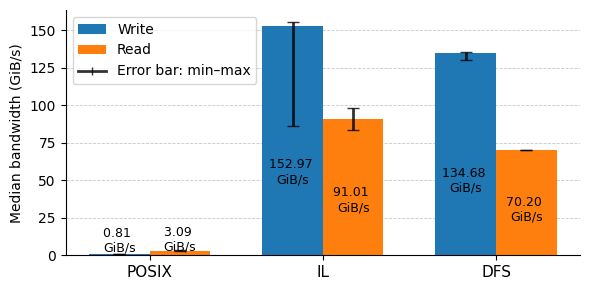

In [17]:
engines_order = ["POSIX", "IL", "DFS"]
tab10 = sns.color_palette("tab10", 10)
ACCESS_COLOR = {"write": tab10[0], "read": tab10[1]}

eng_labels = [e for e in engines_order if e in cmp_df["engine"].values]
x     = np.arange(len(eng_labels))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(6, 3))

for i, access in enumerate(["write", "read"]):
    offset = (i - 0.5) * bar_w
    sub = (
        cmp_df[cmp_df["access"] == access]
        .set_index("engine")
        .reindex(eng_labels)
    )
    medians = sub["median_GiB_s"].values
    mins    = sub["min_GiB_s"].values
    maxs    = sub["max_GiB_s"].values
    xs      = x + offset

    bars = ax.bar(xs, medians, width=bar_w, color=ACCESS_COLOR[access],
                  label=access.capitalize(), edgecolor="none")
    ax.errorbar(xs, medians,
                yerr=[medians - mins, maxs - medians],
                fmt="none", alpha=0.8, ecolor="black", capsize=4, linewidth=2)

    for bar, val in zip(bars, medians):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.3,
            f"{val:.2f} \nGiB/s",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(eng_labels, fontsize=11)
ax.set_ylabel("Median bandwidth (GiB/s)")
cfg = combined[["n", "ppn", "tx"]].iloc[0]
# ax.set_title(f"POSIX vs IL vs DAOS DFS  [n={cfg['n']}, ppn={cfg['ppn']}, tx={cfg['tx']}]")

# Add error-bar handle to legend
from matplotlib.lines import Line2D
eb_handle = Line2D([0], [0], color="black", linewidth=2, alpha=0.8,
                   marker="|", markersize=6, label="Error bar: range (min–max)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [eb_handle], labels + ["Error bar: min–max"])

ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("ior_engine-cmp.pdf", bbox_inches="tight")
plt.show()
